# CoordGen / RDKit ring-system templates

Downloaded from [rdkit/molecular_templates](https://github.com/rdkit/molecular_templates) (`templates.smi`) — CXSMILES with 2D coords sourced from Schrödinger CoordGen (BSD-3).

Local copy: `notebooks/data/coordgen_ring_templates.smi`

These are **ring / macrocycle poses**, not full molecules. RDKit draws them using the embedded coordinates (no `Compute2DCoords`).

In [4]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, SVG, display
from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage, rdMolDraw2D

TEMPLATES = Path("data/coordgen_ring_templates.smi")
if not TEMPLATES.exists():
    # allow running with cwd = repo root
    TEMPLATES = Path("notebooks/data/coordgen_ring_templates.smi")
assert TEMPLATES.exists(), TEMPLATES

print("file:", TEMPLATES.resolve())
print("rdkit", Chem.rdBase.rdkitVersion)

file: /Users/swamidass/Workspaces/xenosite/xenosite-pict/notebooks/data/coordgen_ring_templates.smi
rdkit 2026.03.6


loaded 582 templates (0 parse/coord failures)
atoms: min=5 median=30 max=50


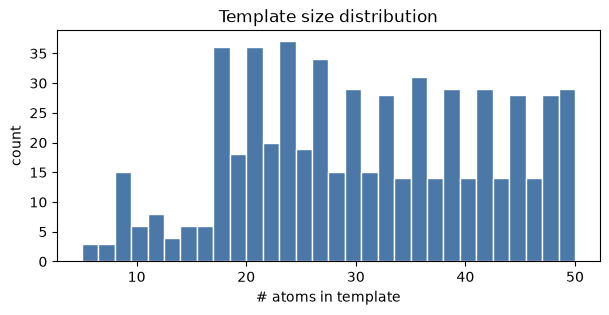

In [5]:
def load_templates(path: Path) -> list[tuple[int, str, Chem.Mol]]:
    out: list[tuple[int, str, Chem.Mol]] = []
    fails = 0
    with path.open() as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            mol = Chem.MolFromSmiles(line)
            if mol is None or mol.GetNumConformers() == 0:
                fails += 1
                continue
            out.append((i, line, mol))
    print(f"loaded {len(out)} templates ({fails} parse/coord failures)")
    return out


templates = load_templates(TEMPLATES)
n_atoms = np.array([m.GetNumAtoms() for _, _, m in templates])
print(
    f"atoms: min={n_atoms.min()} median={int(np.median(n_atoms))} max={n_atoms.max()}"
)

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(n_atoms, bins=30, color="#4c78a8", edgecolor="white")
ax.set_xlabel("# atoms in template")
ax.set_ylabel("count")
ax.set_title("Template size distribution")
plt.show()

In [6]:
def mol_to_svg(mol: Chem.Mol, size: tuple[int, int] = (220, 180)) -> str:
    """Draw using existing conformer coords (do not recompute 2D)."""
    d = rdMolDraw2D.MolDraw2DSVG(*size)
    d.drawOptions().clearBackground = True
    d.drawOptions().addStereoAnnotation = False
    # PrepareMolForDrawing can alter stereo wedges; keep coords.
    rdMolDraw2D.PrepareAndDrawMolecule(d, mol)
    d.FinishDrawing()
    return d.GetDrawingText()


def gallery(
    items: list[tuple[int, str, Chem.Mol]],
    title: str,
    cols: int = 4,
    cell: tuple[int, int] = (220, 180),
) -> HTML:
    cards = []
    for idx, cx, mol in items:
        smiles_only = cx.split(" |", 1)[0]
        svg = mol_to_svg(mol, size=cell)
        # drop xml decl for HTML embed
        if svg.lstrip().startswith("<?xml"):
            svg = svg.split("?>", 1)[-1]
        cards.append(
            "<div style='flex:1 1 22%;min-width:200px;max-width:260px;"
            "border:1px solid #ddd;margin:6px;padding:8px;box-sizing:border-box'>"
            f"<div style='font:600 12px sans-serif'>#{idx} · {mol.GetNumAtoms()} atoms</div>"
            f"<div style='font:11px monospace;color:#555;word-break:break-all;"
            f"max-height:3.2em;overflow:hidden' title='{smiles_only}'>{smiles_only}</div>"
            f"{svg}</div>"
        )
    return HTML(
        f"<h3 style='font:700 15px sans-serif;margin:18px 0 6px'>{title}</h3>"
        f"<div style='display:flex;flex-wrap:wrap'>{''.join(cards)}</div>"
    )

## First 12 (file order)

In [7]:
display(gallery(templates[:12], "First 12 templates"))

## Largest templates

In [8]:
largest = sorted(templates, key=lambda t: t[2].GetNumAtoms(), reverse=True)[:12]
display(gallery(largest, "Largest 12 by atom count"))

## Smallest templates

In [9]:
smallest = sorted(templates, key=lambda t: t[2].GetNumAtoms())[:12]
display(gallery(smallest, "Smallest 12 by atom count"))

## Spread sample (every Nth)

A quick tour across the whole file without drawing all ~580.

In [10]:
step = max(1, len(templates) // 16)
spread = templates[::step][:16]
display(gallery(spread, f"Every {step}th template (16 shown)"))

## RDKit grid image (alternate view)

`MolsToGridImage` also respects conformer coords when present.

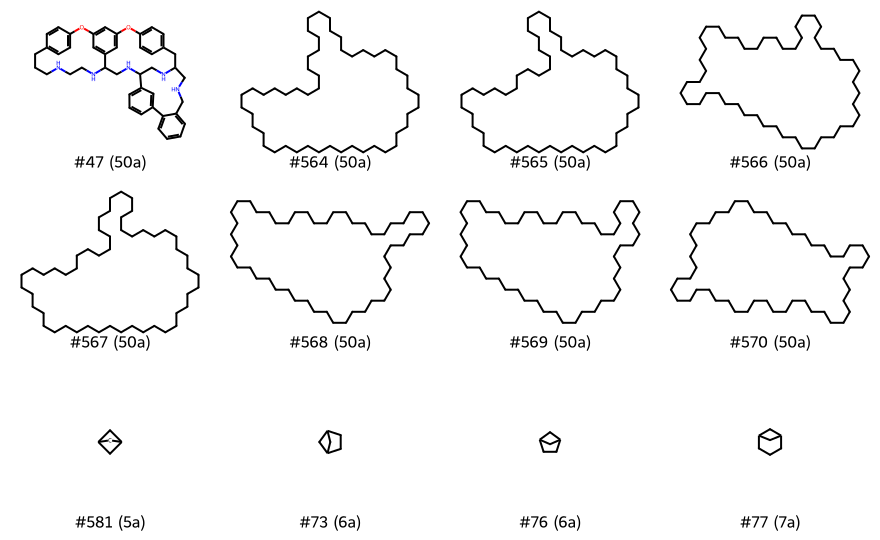

In [11]:
pick = largest[:8] + smallest[:4]
img = MolsToGridImage(
    [m for _, _, m in pick],
    molsPerRow=4,
    subImgSize=(220, 180),
    legends=[f"#{i} ({m.GetNumAtoms()}a)" for i, _, m in pick],
    useSVG=True,
)
display(img)

## Refresh from upstream

```bash
curl -sL https://raw.githubusercontent.com/rdkit/molecular_templates/main/templates.smi \
  -o notebooks/data/coordgen_ring_templates.smi
```